# GPU Logistic Regression Stacker for Playground S6E6

Kaggle's June Playground competition uses metric `balanced accuracy`. Therefore a great stacker to combine/ensemble models is a GPU accelerated multi-class logistic regression stacker. We just load in our OOF and Test PREDS from our models and run this notebook. There is no need to calibrate output predicted probabilities since multi-nominal logistic regression already does this. Also we do not need to calibrate the input probabilities fed into logistic regression. We just feed raw predictions into logistic regression!

In `Version 2` of this logistic regression stacker, we load
* Vladimir's ( @yekenot ) RealMLP (v12) from [here][1] (in dataset [here][28])
* Don's ( @donmarch14 ) TabM (v2) from [here][2] (in dataset [here][28])
* Don's ( @donmarch14 ) XGBoost (v1) from [here][3] (copied [here][17])
* Don's ( @donmarch14 ) CatBoost (v2) from [here][4] (copied [here][18])
* Codex's RealMLP_v1 from [here][5]
* Codex's XGBoost_v1 from [here][6]

In `Version 3` we add 6 more models:
* Kaggler ( @nawfeelrahman1124444 ) RealMLP (v10) from [here][13] (in dataset [here][28])
* Mikhail ( @mikhailnaumov ) XGBoost (v2) from [here][15] (copied [here][16])
* Codex's TabICLv2 from [here][10]
* Codex's LGBM_v3 from [here][11]
* Codex's Log Reg v1 from [here][12]
* Codex's NN_v1 from [here][14]

In `Version 4` we add my new `LB 0.96801` XGB:
* Codex's XGBoost_v5 from [here][19]

In `Version 6` we add 2 more models including my new `LB 0.96979` RealMLP!:
* Codex's RealMLP_v5 [here][20]
* Codex's NN_v2 [here][21]

In `Version 7` we add my new `LB 0.96972` CAT:
* Codex's CatBoost_v3 from [here][22]

In `Version 8` we add 3 more models including Cstdy's `one-vs-rest` models:
* Omid ( @omidbaghchehsaraei ) LGBM (v1) from [here][24] (in dataset [here][28])
* Cstdy ( @kirill0212 ) XGBoost (v1) from [here][26] (in dataset [here][28])
* Cstdy ( @kirill0212 ) TabM (v1) from [here][27] (in dataset [here][28])

In `Version 9` we load (other Kagglers') OOF and Test PREDS from dataset [here][28] for correct notebook versions.

To improve this notebook's CV and LB score, just create more models and add their OOF and Test PREDS to a forked copy of this notebook! Discussion about this notebook is [here][9]. Good luck, have fun!

[1]: https://www.kaggle.com/code/yekenot/ps-s6-e6-realmlp-pytorch?scriptVersionId=324087390
[2]: https://www.kaggle.com/code/donmarch14/s6e6-tabm?scriptVersionId=323695236
[3]: https://www.kaggle.com/code/donmarch14/s6e6-xgboost?scriptVersionId=323616155
[4]: https://www.kaggle.com/code/donmarch14/s6e6-catboost?scriptVersionId=323646390
[5]: https://www.kaggle.com/code/cdeotte/realmlp-v1-for-s6e6
[6]: https://www.kaggle.com/code/cdeotte/xgb-v1-for-s6e6
[7]: https://www.kaggle.com/code/cdeotte/lgbm-v1-for-s6e6
[8]: https://www.kaggle.com/code/cdeotte/realmlp-v2-for-s6e6
[9]: https://www.kaggle.com/competitions/playground-series-s6e6/discussion/704014
[10]: https://www.kaggle.com/code/cdeotte/tabicl-v2-for-s6e6/notebook
[11]: https://www.kaggle.com/code/cdeotte/lgbm-v3-for-s6e6
[12]: https://www.kaggle.com/code/cdeotte/logreg-v1-for-s6e6
[13]: https://www.kaggle.com/code/nawfeelrahman1124444/single-realmlp-0-96980-v10?scriptVersionId=324145704
[14]: https://www.kaggle.com/code/cdeotte/nn-v1-for-s6e6/notebook
[15]: https://www.kaggle.com/code/mikhailnaumov/stellar-class-xgb?scriptVersionId=324309248
[16]: https://www.kaggle.com/code/cdeotte/xgb-v3-for-s6e6
[17]: https://www.kaggle.com/code/cdeotte/xgb-v0-for-s6e6
[18]: https://www.kaggle.com/code/cdeotte/cat-v0-for-s6e6
[19]: https://www.kaggle.com/code/cdeotte/xgb-v5-for-s6e6
[20]: https://www.kaggle.com/code/cdeotte/realmlp-v5-for-s6e6/
[21]: https://www.kaggle.com/code/cdeotte/nn-v2-for-s6e6/
[22]: https://www.kaggle.com/code/cdeotte/cat-v3-for-s6e6
[23]: https://www.kaggle.com/code/cdeotte/single-lightgbm-lb-0-96728
[24]: https://www.kaggle.com/code/omidbaghchehsaraei/lightgbm-stellar-class-cv-0-96816-lb-0-96885?scriptVersionId=324816757
[25]: https://www.kaggle.com/code/evgendvorkin/single-lightgbm-lb-0-96728
[26]: https://www.kaggle.com/code/kirill0212/ps6e6-one-vs-rest-xgb?scriptVersionId=324872761
[27]: https://www.kaggle.com/code/kirill0212/ps6e6-one-vs-rest-tabm?scriptVersionId=324873119
[28]: https://www.kaggle.com/datasets/cdeotte/s6e6-oof-and-test-preds

In [1]:
import numpy as np
import pandas as pd
import warnings
import gc
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

N_FOLDS     = 5
N_SEEDS     = 5
SEEDS       = list(range(42, 42 + N_SEEDS))
EPS         = 1e-15
LOGIT_CLIP  = 30.0
epochs      = 1000
C           = 1e-1

TARGET      = 'class'
target_map  = {'GALAXY': 0, 'QSO': 1, 'STAR': 2}
inv_map     = {v: k for k, v in target_map.items()}
BOOST       = 1.0

VER         = 9

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Seeds: {SEEDS}')

class PyTorchMultiLogReg(nn.Module):
    def __init__(self, in_features, out_features=3):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x):
        return self.linear(x)

# Format: ('MODEL_NAME', 'oof_file.npy', 'test_file.npy')
# Update paths here if your model outputs live in another folder.
STACKING_FILES = [
    ### Version 2 ###
    ('xgb-0', '/kaggle/input/notebooks/cdeotte/xgb-v0-for-s6e6/oof_xgb_cv.csv', '/kaggle/input/notebooks/cdeotte/xgb-v0-for-s6e6/test_xgb_preds.csv'),
    ('xgb-1', '/kaggle/input/notebooks/cdeotte/xgb-v1-for-s6e6/oof_preds.npy', '/kaggle/input/notebooks/cdeotte/xgb-v1-for-s6e6/test_preds.npy'),
    ('realmlp-0', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/oof_preds_realmlp0_v12.csv', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/test_preds_realmlp0_v12.csv'),
    ('realmlp-1', '/kaggle/input/notebooks/cdeotte/realmlp-v1-for-s6e6/oof_preds.npy', '/kaggle/input/notebooks/cdeotte/realmlp-v1-for-s6e6/test_preds.npy'),
    ('tabm-0', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/oof_preds_tabm0_v2.csv', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/test_preds_tabm0_v2.csv'),
    ('cat-0', '/kaggle/input/notebooks/cdeotte/cat-v0-for-s6e6/catboost_oof_predictions.csv', '/kaggle/input/notebooks/cdeotte/cat-v0-for-s6e6/catboost_test_predictions.csv'),
    ### Version 3 ###
    ('realmlp-2', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/oof_preds_realmlp2_v10.csv', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/test_preds_realmlp2_v10.csv'),
    ('tabicl-2', '/kaggle/input/notebooks/cdeotte/tabicl-v2-for-s6e6/train_oof/tabicl-2_oof.npy', '/kaggle/input/notebooks/cdeotte/tabicl-v2-for-s6e6/test_preds/tabicl-2_test_preds.npy'),
    ('lgbm-3', '/kaggle/input/notebooks/cdeotte/lgbm-v3-for-s6e6/train_oof/lgbm-3_oof.npy', '/kaggle/input/notebooks/cdeotte/lgbm-v3-for-s6e6/test_preds/lgbm-3_test_preds.npy'),
    ('logreg-1', '/kaggle/input/notebooks/cdeotte/logreg-v1-for-s6e6/train_oof/logreg-1_oof.npy', '/kaggle/input/notebooks/cdeotte/logreg-v1-for-s6e6/test_preds/logreg-1_test_preds.npy'),
    ('nn-1', '/kaggle/input/notebooks/cdeotte/nn-v1-for-s6e6/train_oof/nn-1_oof.npy', '/kaggle/input/notebooks/cdeotte/nn-v1-for-s6e6/test_preds/nn-1_test_preds.npy'),
    ('xgb-3', '/kaggle/input/notebooks/cdeotte/xgb-v3-for-s6e6/stellar_class_xgb_oof_preds_raw.npy', '/kaggle/input/notebooks/cdeotte/xgb-v3-for-s6e6/stellar_class_xgb_test_preds_raw.npy'),
    ### Version 4 ###
    ('xgb-5', '/kaggle/input/notebooks/cdeotte/xgb-v5-for-s6e6/train_oof/xgb-5_oof.npy', '/kaggle/input/notebooks/cdeotte/xgb-v5-for-s6e6/test_preds/xgb-5_test_preds.npy'),
    ### Version 6 ###
    ('realmlp-5', '/kaggle/input/notebooks/cdeotte/realmlp-v5-for-s6e6/train_oof/realmlp-5_oof.npy', '/kaggle/input/notebooks/cdeotte/realmlp-v5-for-s6e6/test_preds/realmlp-5_test_preds.npy'),
    ('nn-2', '/kaggle/input/notebooks/cdeotte/nn-v2-for-s6e6/train_oof/nn-2_oof.npy', '/kaggle/input/notebooks/cdeotte/nn-v2-for-s6e6/test_preds/nn-2_test_preds.npy'),
    ### Version 7 ###
    ('cat-3', '/kaggle/input/notebooks/cdeotte/cat-v3-for-s6e6/train_oof/cat-3_oof.npy', '/kaggle/input/notebooks/cdeotte/cat-v3-for-s6e6/test_preds/cat-3_test_preds.npy'),
    ### Version 8 ###
    ('lgbm-5', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/oof_preds_lgbm5_v1.csv', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/test_preds_lgbm5_v1.csv'),
    ('xgb-6', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/oof_final_xgb6_v1.csv', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/test_final_xgb6_v1.csv'),
    ('tabm-1', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/oof_final_tabm1_v1.csv', '/kaggle/input/datasets/cdeotte/s6e6-oof-and-test-preds/test_final_tabm1_v1.csv'),
]

print(f'Total models: {len(STACKING_FILES)}')

Using device: cuda
Seeds: [42, 43, 44, 45, 46]
Total models: 19


In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/train.csv', index_col='id')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/test.csv',  index_col='id')

y = train[TARGET].map(target_map).astype(int).values
N = len(y)
M = len(test)
print(f'Train: {N:,} | Test: {M:,}')
print(f'Class dist: {dict(zip(*np.unique(y, return_counts=True)))}')

def prob_to_logit(p):
    p = np.clip(p, EPS, 1.0 - EPS).astype(np.float64)
    return np.clip(np.log(p / (1.0 - p)), -LOGIT_CLIP, LOGIT_CLIP).astype(np.float32)

def load_preds(path, expected_rows=None):
    if path.lower().endswith(".csv"):
        df = pd.read_csv(path)

        # Case 1: broken flattened CSV with one column of length expected_rows * 3
        if df.shape[1] == 1:
            vals = df.iloc[:, 0].values

            if expected_rows is not None:
                assert len(vals) == expected_rows * 3, (
                    f'{path}: one-column CSV has length {len(vals)}, '
                    f'expected {expected_rows * 3}'
                )

            assert len(vals) % 3 == 0, (
                f'{path}: one-column CSV length {len(vals)} is not divisible by 3'
            )

            return vals.reshape(-1, 3)

        # Case 2: normal CSV; use last 3 columns as probabilities
        return df.iloc[:, -3:].values[:expected_rows]

    arr = np.load(path)

    if arr.ndim == 3:
        arr = arr.mean(axis=0)

    return arr

loaded_oofs  = []
loaded_tests = []
display_names = []

print('\nLoading models:')
for name, oof_f, test_f in STACKING_FILES:
    try:
        o = load_preds(oof_f, expected_rows=N)
        o = prob_to_logit(o)

        t = load_preds(test_f, expected_rows=M)
        t = prob_to_logit(t)

        assert o.shape == (N, 3), f'OOF shape {o.shape} != {(N, 3)}'
        assert t.shape == (M, 3), f'Test shape {t.shape} != {(M, 3)}'

        loaded_oofs.append(o)
        loaded_tests.append(t)
        display_names.append(name)

        print(f'  {name:20s} OOF={o.shape} TEST={t.shape}')

    except Exception as e:
        print(f'  SKIP {name} ({oof_f}, {test_f}): {e}')

n_models = len(loaded_oofs)
if n_models == 0:
    raise RuntimeError('No stacking files loaded. Update STACKING_FILES paths and rerun.')

print(f'\nModels: {n_models} | LR input features: {n_models * 3}')

X_test = np.concatenate(loaded_tests, axis=1).astype(np.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

Train: 577,347 | Test: 247,435
Class dist: {np.int64(0): np.int64(377480), np.int64(1): np.int64(117143), np.int64(2): np.int64(82724)}

Loading models:
  xgb-0                OOF=(577347, 3) TEST=(247435, 3)
  xgb-1                OOF=(577347, 3) TEST=(247435, 3)
  realmlp-0            OOF=(577347, 3) TEST=(247435, 3)
  realmlp-1            OOF=(577347, 3) TEST=(247435, 3)
  tabm-0               OOF=(577347, 3) TEST=(247435, 3)
  cat-0                OOF=(577347, 3) TEST=(247435, 3)
  realmlp-2            OOF=(577347, 3) TEST=(247435, 3)
  tabicl-2             OOF=(577347, 3) TEST=(247435, 3)
  lgbm-3               OOF=(577347, 3) TEST=(247435, 3)
  logreg-1             OOF=(577347, 3) TEST=(247435, 3)
  nn-1                 OOF=(577347, 3) TEST=(247435, 3)
  xgb-3                OOF=(577347, 3) TEST=(247435, 3)
  xgb-5                OOF=(577347, 3) TEST=(247435, 3)
  realmlp-5            OOF=(577347, 3) TEST=(247435, 3)
  nn-2                 OOF=(577347, 3) TEST=(247435, 3)
  cat-3

Seed 42 fold 1: BAC=0.971073 | 8.3s
Seed 42 fold 2: BAC=0.969871 | 2.6s
Seed 42 fold 3: BAC=0.969598 | 2.6s
Seed 42 fold 4: BAC=0.969598 | 2.6s
Seed 42 fold 5: BAC=0.970324 | 2.6s
Seed 42: OOF BAC=0.970093 | folds=['0.971073', '0.969871', '0.969598', '0.969598', '0.970324']
Seed 43 fold 1: BAC=0.969967 | 2.6s
Seed 43 fold 2: BAC=0.971080 | 2.7s
Seed 43 fold 3: BAC=0.970809 | 2.7s
Seed 43 fold 4: BAC=0.969366 | 2.7s
Seed 43 fold 5: BAC=0.969649 | 2.7s
Seed 43: OOF BAC=0.970174 | folds=['0.969967', '0.971080', '0.970809', '0.969366', '0.969649']
Seed 44 fold 1: BAC=0.970467 | 2.7s
Seed 44 fold 2: BAC=0.970365 | 2.7s
Seed 44 fold 3: BAC=0.970130 | 2.7s
Seed 44 fold 4: BAC=0.969967 | 2.8s
Seed 44 fold 5: BAC=0.970199 | 2.8s
Seed 44: OOF BAC=0.970226 | folds=['0.970467', '0.970365', '0.970130', '0.969967', '0.970199']
Seed 45 fold 1: BAC=0.969872 | 2.8s
Seed 45 fold 2: BAC=0.969943 | 2.8s
Seed 45 fold 3: BAC=0.970258 | 2.9s
Seed 45 fold 4: BAC=0.970990 | 2.9s
Seed 45 fold 5: BAC=0.970050 | 

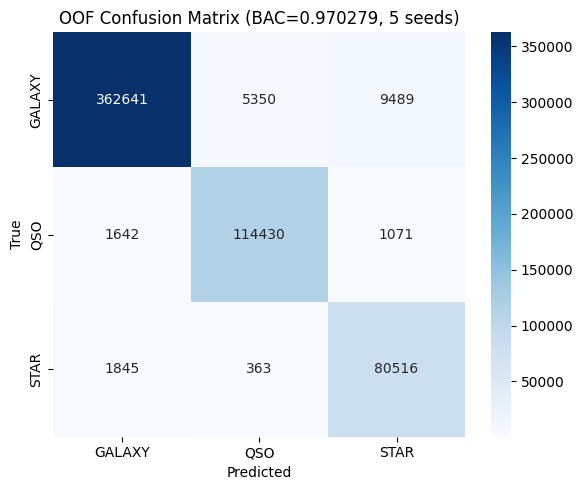

In [3]:
oof_sum    = np.zeros((N, 3), dtype=np.float64)
test_sum   = np.zeros((M, 3), dtype=np.float64)
all_fold_accs = []
X_oof_matrix = np.zeros((N, n_models * 3), dtype=np.float32)

for si, seed in enumerate(SEEDS):
    set_seed(seed)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    oof_this  = np.zeros((N, 3), dtype=np.float32)
    test_this = np.zeros((M, 3), dtype=np.float32)
    seed_accs = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(np.zeros(N), y), start=1):
        t0 = time.time()

        meta_tr, meta_va = [], []
        for o in loaded_oofs:
            meta_tr.append(o[tr_idx, :])
            meta_va.append(o[val_idx, :])

        X_tr  = np.concatenate(meta_tr, axis=1).astype(np.float32)
        X_val = np.concatenate(meta_va, axis=1).astype(np.float32)

        if si == len(SEEDS) - 1:
            X_oof_matrix[val_idx, :] = X_val

        y_tr  = y[tr_idx]
        y_val = y[val_idx]

        classes = np.unique(y_tr)
        cw = compute_class_weight('balanced', classes=classes, y=y_tr)
        class_weight = dict(zip(classes, cw))
        class_weight[2] = class_weight[2] * BOOST
        sample_weights = np.array([class_weight[c] for c in y_tr], dtype=np.float32)

        X_tr_t  = torch.tensor(X_tr, dtype=torch.float32, device=device)
        y_tr_t  = torch.tensor(y_tr, dtype=torch.long, device=device)
        sw_t    = torch.tensor(sample_weights, dtype=torch.float32, device=device)
        X_val_t = torch.tensor(X_val, dtype=torch.float32, device=device)

        model = PyTorchMultiLogReg(in_features=X_tr.shape[1], out_features=3).to(device)
        criterion = nn.CrossEntropyLoss(reduction='none')
        weight_decay_mapped = 1.0 / (C * len(y_tr))
        optimizer = optim.Adam([
            {'params': model.linear.weight, 'weight_decay': weight_decay_mapped},
            {'params': model.linear.bias, 'weight_decay': 0.0},
        ], lr=0.01)

        model.train()
        for _ in range(epochs):
            optimizer.zero_grad()
            logits = model(X_tr_t)
            loss = (criterion(logits, y_tr_t) * sw_t).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_prob = torch.softmax(model(X_val_t), dim=1).cpu().numpy()
            oof_this[val_idx] = val_prob
            test_this += torch.softmax(model(X_test_tensor), dim=1).cpu().numpy() / N_FOLDS

        fold_acc = balanced_accuracy_score(y_val, np.argmax(val_prob, axis=1))
        seed_accs.append(fold_acc)
        print(f'Seed {seed} fold {fold}: BAC={fold_acc:.6f} | {time.time() - t0:.1f}s')

        del model, X_tr_t, y_tr_t, sw_t, X_val_t, X_tr, X_val
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    oof_sum  += oof_this
    test_sum += test_this

    seed_bac = balanced_accuracy_score(y, np.argmax(oof_this, axis=1))
    all_fold_accs.extend(seed_accs)
    print(f'Seed {seed}: OOF BAC={seed_bac:.6f} | folds={[f"{a:.6f}" for a in seed_accs]}')

oof = (oof_sum / N_SEEDS).astype(np.float32)
test_preds = (test_sum / N_SEEDS).astype(np.float32)

oof_hard = np.argmax(oof, axis=1)
overall = balanced_accuracy_score(y, oof_hard)
print(f'\nMean fold ACC across all {N_SEEDS * N_FOLDS} folds: {np.mean(all_fold_accs):.6f} +/- {np.std(all_fold_accs):.6f}')
print(f'Overall OOF Balanced ACC ({N_SEEDS}-seed avg): {overall:.6f}')

for k, label in inv_map.items():
    mask = (y == k)
    cls_acc = (oof_hard[mask] == k).mean()
    print(f'  {label:>6s} accuracy: {cls_acc:.6f}  ({(oof_hard[mask] == k).sum()}/{mask.sum()})')

cm = confusion_matrix(y, oof_hard)
print('\nConfusion Matrix (rows=true, cols=pred):')
print(pd.DataFrame(cm, index=[f'True {inv_map[i]}' for i in range(3)], columns=[f'Pred {inv_map[i]}' for i in range(3)]))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[inv_map[i] for i in range(3)],
            yticklabels=[inv_map[i] for i in range(3)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'OOF Confusion Matrix (BAC={overall:.6f}, {N_SEEDS} seeds)')
plt.tight_layout()
plt.show()

In [4]:
np.save(f'oof_lr_stacker_v{VER}.npy', oof)
np.save(f'pred_lr_stacker_v{VER}.npy', test_preds)
#np.save(f'stacker{VER}_oof_preds.npy', oof)
#np.save(f'stacker{VER}_test_preds.npy', test_preds)
print(f'Saved oof_lr_stacker_v{VER}.npy  shape={oof.shape}')
print(f'Saved pred_lr_stacker_v{VER}.npy shape={test_preds.shape}')

sub = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv')
sub[TARGET] = np.argmax(test_preds, axis=1)
sub[TARGET] = sub[TARGET].map(inv_map)
#sub.to_csv(f'LR_stacker_{VER}.csv', index=False)
sub.to_csv('submission.csv', index=False)
print(f'\nSubmission saved: submission.csv')
print(sub[TARGET].value_counts())


Saved oof_lr_stacker_v9.npy  shape=(577347, 3)
Saved pred_lr_stacker_v9.npy shape=(247435, 3)

Submission saved: submission.csv
class
GALAXY    156993
QSO        51452
STAR       38990
Name: count, dtype: int64


--- Training Dedicated 100% Data Model for Standardized Feature Importance ---

--- Standardized Model Feature Importances ---


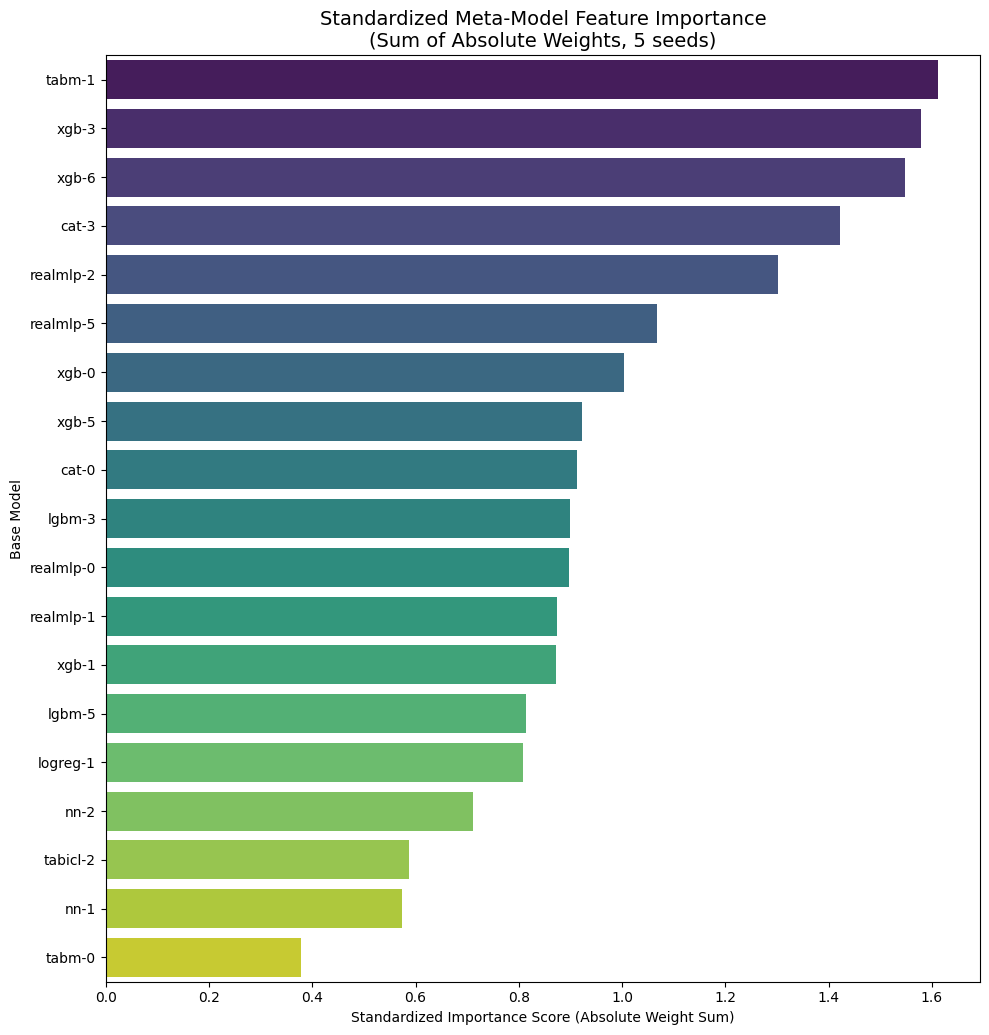

In [5]:
print('--- Training Dedicated 100% Data Model for Standardized Feature Importance ---')
scaler = StandardScaler()
X_oof_scaled = scaler.fit_transform(X_oof_matrix)

X_full_t = torch.tensor(X_oof_scaled, dtype=torch.float32, device=device)
y_full_t = torch.tensor(y, dtype=torch.long, device=device)

classes = np.unique(y)
cw = compute_class_weight('balanced', classes=classes, y=y)
class_weight = dict(zip(classes, cw))
class_weight[2] = class_weight[2] * BOOST
sw_full = np.array([class_weight[c] for c in y], dtype=np.float32)
sw_full_t = torch.tensor(sw_full, dtype=torch.float32, device=device)

imp_model = PyTorchMultiLogReg(in_features=X_oof_matrix.shape[1], out_features=3).to(device)
criterion = nn.CrossEntropyLoss(reduction='none')
C_imp = 1.0
weight_decay_mapped = 1.0 / (C_imp * len(y))
optimizer = optim.Adam([
    {'params': imp_model.linear.weight, 'weight_decay': weight_decay_mapped},
    {'params': imp_model.linear.bias, 'weight_decay': 0.0},
], lr=0.01)

imp_model.train()
for _ in range(epochs):
    optimizer.zero_grad()
    logits = imp_model(X_full_t)
    loss = (criterion(logits, y_full_t) * sw_full_t).mean()
    loss.backward()
    optimizer.step()

imp_weights = imp_model.linear.weight.detach().cpu().numpy()
del imp_model, X_full_t, y_full_t, sw_full_t
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

print('\n--- Standardized Model Feature Importances ---')

model_importances = []
for i in range(n_models):
    block = imp_weights[:, i*3 : (i+1)*3]
    class_row_importance = np.sum(np.abs(block), axis=1)
    model_importances.append({
        'Model': display_names[i],
        'Total': float(class_row_importance.sum()),
        'GALAXY': float(class_row_importance[0]),
        'QSO': float(class_row_importance[1]),
        'STAR': float(class_row_importance[2]),
    })

df_imp = pd.DataFrame(model_importances)

plt.figure(figsize=(10, max(4, n_models * 0.55)))
sns.barplot(x='Total', y='Model', data=df_imp.sort_values(by='Total', ascending=False), palette='viridis')
plt.title(f'Standardized Meta-Model Feature Importance\n(Sum of Absolute Weights, {N_SEEDS} seeds)', fontsize=14)
plt.xlabel('Standardized Importance Score (Absolute Weight Sum)')
plt.ylabel('Base Model')
plt.tight_layout()
plt.show()
